Connection to online passbands at https://tables.phoebe-project.org could not be established.  Check your internet connection or try again later (can manually call phoebe.list_online_passbands(refresh=True) to retry).  If the problem persists and you're using a Mac, you may need to update openssl (see https://phoebe-project.org/help/faq). Original error from urlopen: URLError <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>
['estimator.ebai', 'estimator.lc_geometry', 'estimator.lc_periodogram', 'estimator.rv_geometry', 'estimator.rv_periodogram', 'optimizer.cg', 'optimizer.differential_corrections', 'optimizer.differential_evolution', 'optimizer.nelder_mead', 'optimizer.powell', 'sampler.dynesty', 'sampler.emcee']


Tue, 19 May 2026 15:56 PASSBANDS    WARNING Online passbands unavailable (reached max tries).  Pass refresh=True to force another attempt or repeat_errors=False to avoid showing this message.
Tue, 19 May 2026 15:56 PASSBANDS    WARNING Online passbands unavailable (reached max tries).  Pass refresh=True to force another attempt or repeat_errors=False to avoid showing this message.
100%|██████████| 101/101 [00:00<00:00, 108.27it/s]


ParameterSet: 10 parameters
   comments@my_lcgeom_solver@s...: 
   use_server@my_lcgeom_solver...: none
   lc_datasets@my_lcgeom_solve...: ['*']
   phase_bin@my_lcgeom_solver@...: True
   phase_nbins@my_lcgeom_solve...: 500
    orbit@my_lcgeom_solver@solver: binary
   analytical_model@my_lcgeom_...: two-gaussian
   interactive@my_lcgeom_solve...: False
   t0_near_times@my_lcgeom_sol...: True
   expose_model@my_lcgeom_solv...: True


Tue, 19 May 2026 15:56 PASSBANDS    WARNING Online passbands unavailable (reached max tries).  Pass refresh=True to force another attempt or repeat_errors=False to avoid showing this message.
100%|██████████| 101/101 [00:01<00:00, 52.66it/s]
Tue, 19 May 2026 15:56 BUNDLE       WARNING ignoring distribution on teff@primary@star@component with distribution='mydist02' as distribution existed on an earlier distribution which takes precedence.


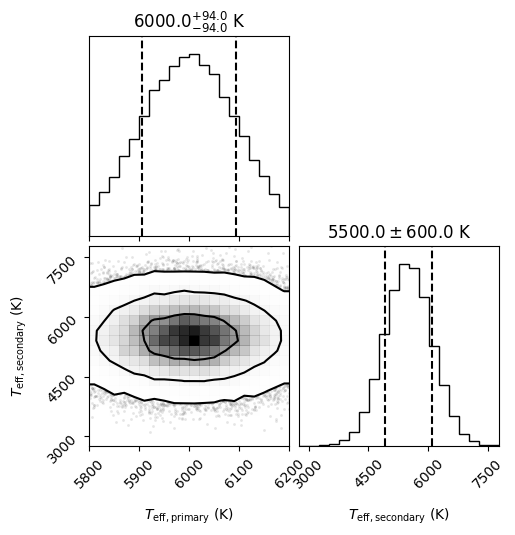

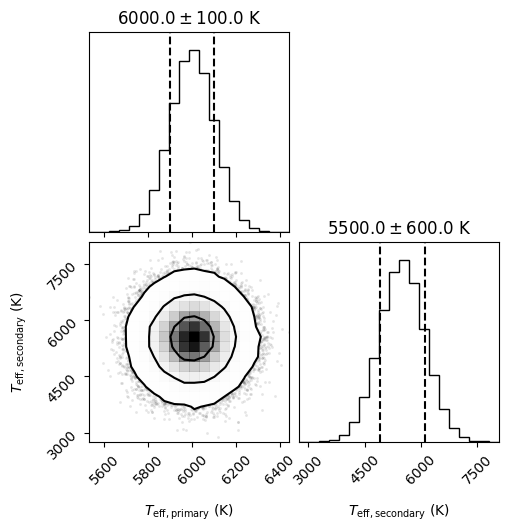

In [ ]:
import phoebe
from phoebe import u # units
import numpy as np
import sys
import matplotlib.pyplot as plt

%matplotlib inline

logger = phoebe.logger()

print(phoebe.list_available_solvers())

b = phoebe.default_binary()
b.add_dataset('lc', compute_phases=phoebe.linspace(0,1,101))
b.run_compute(irrad_method='none')

times = b.get_value('times', context='model')
fluxes = b.get_value('fluxes', context='model') + np.random.normal(size=times.shape) * 0.01
sigmas = np.ones_like(times) * 0.02

b = phoebe.default_binary()
b.add_dataset('lc', times=times, fluxes=fluxes, sigmas=np.full_like(fluxes, fill_value=0.1))

b.add_solver('estimator.lc_geometry', solver='my_lcgeom_solver')

print(b.get_solver(solver='my_lcgeom_solver'))

b.run_solver(solver='my_lcgeom_solver', solution='my_lcgeom_solution')

b_model = b.copy()

b_model.flip_constraint('requivsumfrac', solve_for='requiv@secondary')
b_model.flip_constraint('teffratio', solve_for='teff@secondary')

b_model.adopt_solution(solution='my_lcgeom_solution')
b_model.run_compute(irrad_method='none', model='lcgeom_model')

time_model = b_model.get_value('times', context='model', model='lcgeom_model')
fluxes_model = b_model.get_value('fluxes', context='model', model='lcgeom_model')

#plt.errorbar(time_model, fluxes_model, yerr=sigmas, fmt='.', color='black')
#plt.plot(time_model, fluxes_model, label='Model from LC Geometric Solver', color='black')
#plt.xlabel('Time')
#plt.ylabel('Flux')
#plt.legend()
#plt.show()

b.add_distribution('teff@primary', phoebe.gaussian(6000,100), distribution='mydist01')
b.add_distribution('teff@secondary', phoebe.gaussian(5500,600), distribution='mydist01')

b.add_distribution('teff@primary', phoebe.uniform(5800,6200), distribution='mydist02')

b.add_solver('sampler.emcee', priors=['mydist01', 'mydist02'], solver='myemceesolver')

_ = b.plot_distribution_collection('priors@myemceesolver', show=True)

b.calculate_lnp('priors@myemceesolver')

#sets the prior used to the first one in the 'priors_combine' list
b.set_value('priors_combine', 'first')

_ = b.plot_distribution_collection('priors@myemceesolver', show=True)

Connection to online passbands at https://tables.phoebe-project.org could not be established.  Check your internet connection or try again later (can manually call phoebe.list_online_passbands(refresh=True) to retry).  If the problem persists and you're using a Mac, you may need to update openssl (see https://phoebe-project.org/help/faq). Original error from urlopen: URLError <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>


100%|██████████| 201/201 [00:06<00:00, 32.62it/s]
/Users/kylechen/phoebe-env/lib/python3.11/site-packages/phoebe/dependencies/autofig/call.py:1305: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  artist = ax.scatter(*datapoint,


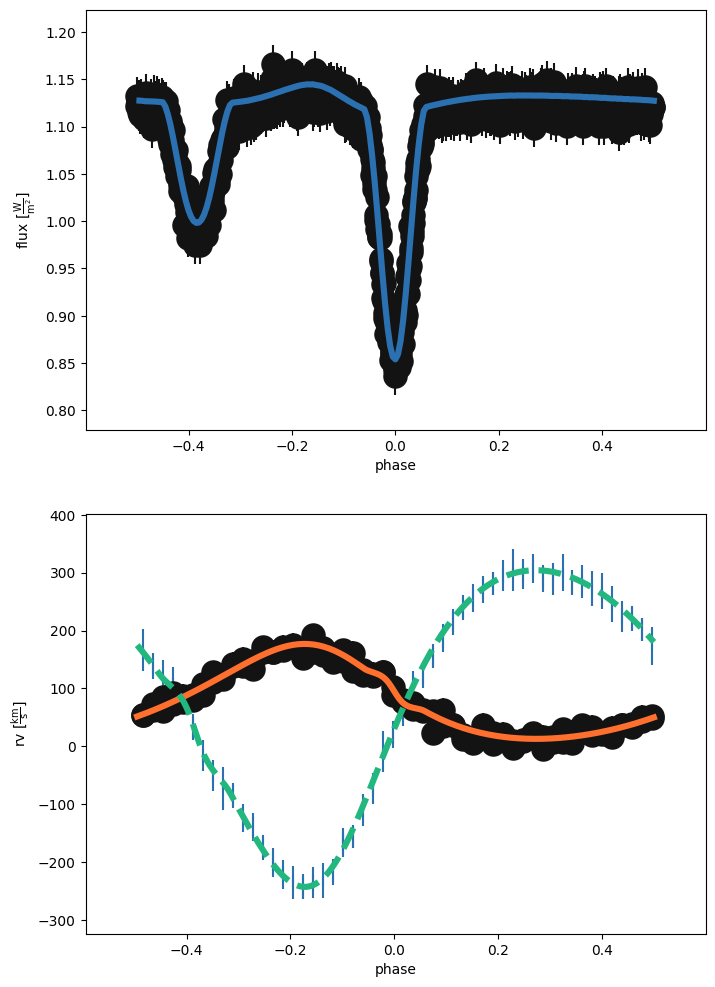

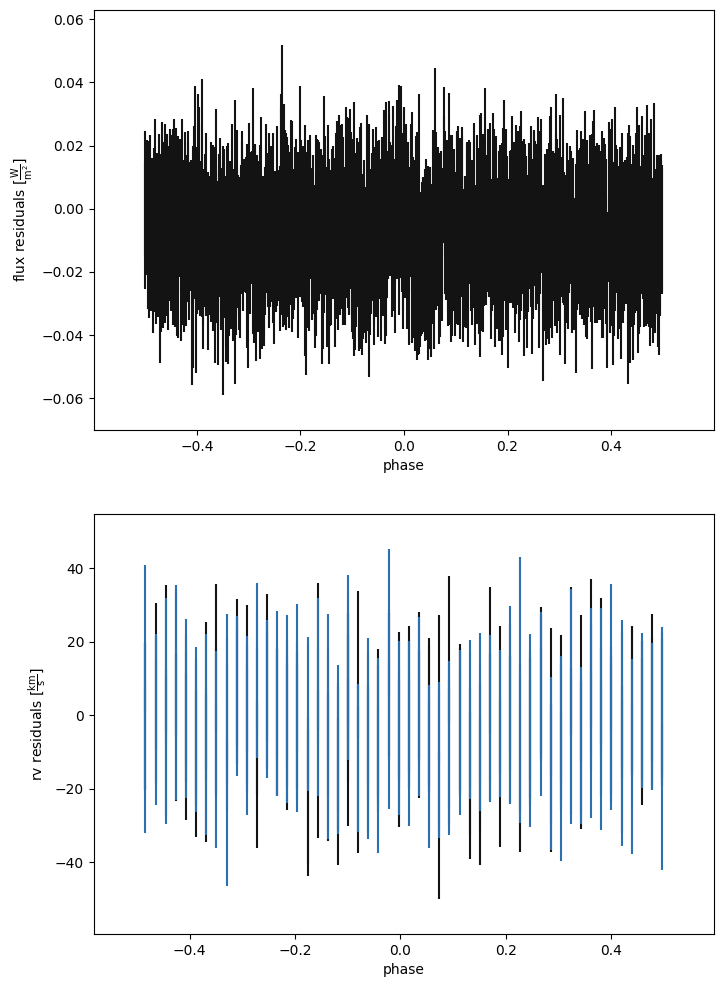

In [1]:
import phoebe
from phoebe import u # units
import numpy as np

%matplotlib inline

logger = phoebe.logger('error')

b = phoebe.default_binary()
b.set_value('ecc', 0.2)
b.set_value('per0', 25)
b.set_value('teff@primary', 7000)
b.set_value('teff@secondary', 6000)
b.set_value('sma@binary', 7)
b.set_value('incl@binary', 80)
b.set_value('q', 0.3)
b.set_value('t0_supconj', 0.1)
b.set_value('requiv@primary', 2.0)
b.set_value('vgamma', 80)

lctimes = phoebe.linspace(0, 10, 1005)
rvtimes = phoebe.linspace(0, 10, 105)
b.add_dataset('lc', compute_times=lctimes)
b.add_dataset('rv', compute_times=rvtimes)

b.add_compute('phoebe', compute='fastcompute')
b.set_value_all('ld_mode', 'lookup')
b.run_compute(compute='fastcompute')

fluxes = b.get_value('fluxes@model') + np.random.normal(size=lctimes.shape) * 0.01
fsigmas = np.ones_like(lctimes) * 0.02

rvsA = b.get_value('rvs@primary@model') + np.random.normal(size=rvtimes.shape) * 10
rvsB = b.get_value('rvs@secondary@model') + np.random.normal(size=rvtimes.shape) * 10
rvsigmas = np.ones_like(rvtimes) * 20

b = phoebe.default_binary()

b.add_dataset('lc', 
              compute_phases=phoebe.linspace(0,1,201),
              times=lctimes, 
              fluxes=fluxes, 
              sigmas=fsigmas, 
              dataset='lc01')

b.add_dataset('rv', 
              compute_phases=phoebe.linspace(0,1,201),
              times=rvtimes, 
              rvs={'primary': rvsA, 'secondary': rvsB}, 
              sigmas=rvsigmas, 
              dataset='rv01')

b.add_compute('phoebe', compute='fastcompute')
b.set_value_all('ld_mode', 'lookup')

b.set_value('ecc', 0.2)
b.set_value('per0', 25)
b.set_value('teff@primary', 7000)
b.set_value('teff@secondary', 6000)
b.set_value('sma@binary', 7+0.01)
b.set_value('incl@binary', 80+0.1)
b.set_value('q', 0.3)
b.set_value('t0_supconj', 0.1-0.001)
b.set_value('requiv@primary', 2.0-0.05)
b.set_value('vgamma', 80)
b.run_compute(compute='fastcompute', model='orig_model')

_ = b.plot(x='phases', show=True)
_ = b.plot(x='phases', y='residuals', show=True)


  0%|          | 0/20 [00:00<?, ?it/s]

Connection to online passbands at https://tables.phoebe-project.org could not be established.  Check your internet connection or try again later (can manually call phoebe.list_online_passbands(refresh=True) to retry).  If the problem persists and you're using a Mac, you may need to update openssl (see https://phoebe-project.org/help/faq). Original error from urlopen: URLError <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>
Connection to online passbands at https://tables.phoebe-project.org could not be established.  Check your internet connection or try again later (can manually call phoebe.list_online_passbands(refresh=True) to retry).  If the problem persists and you're using a Mac, you may need to update openssl (see https://phoebe-project.org/help/faq). Original error from urlopen: URLError <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate

100%|██████████| 20/20 [00:19<00:00,  1.02it/s]


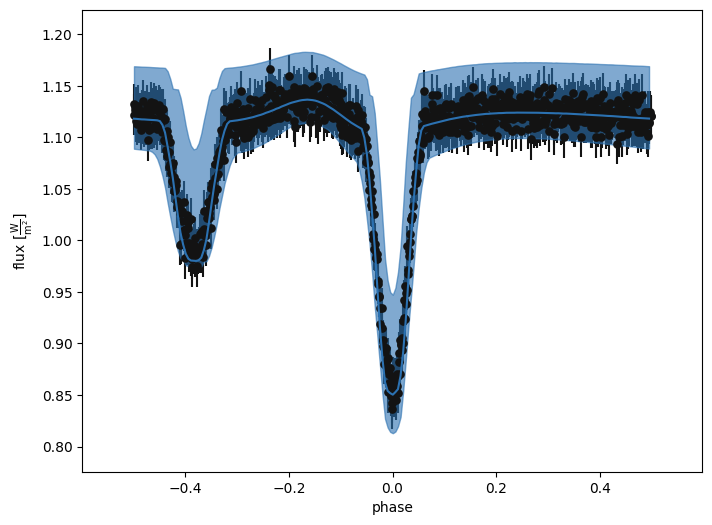

/Users/kylechen/phoebe-env/lib/python3.11/site-packages/phoebe/dependencies/autofig/call.py:1305: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  artist = ax.scatter(*datapoint,


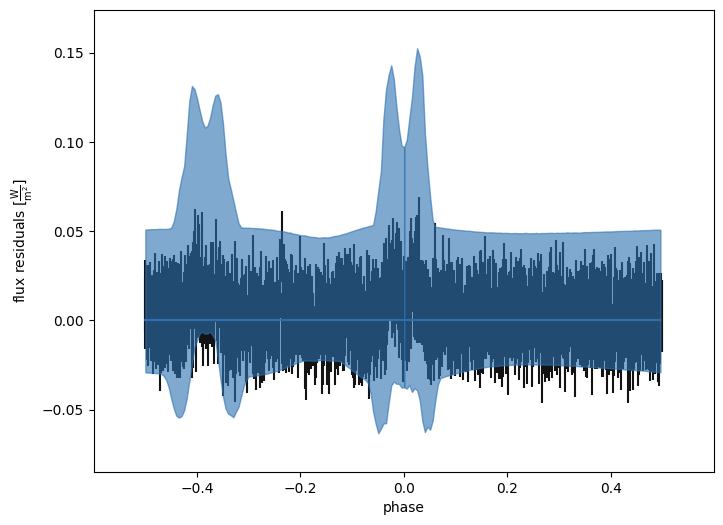

<ParameterSet: 24 parameters | components: primary, secondary, binary>

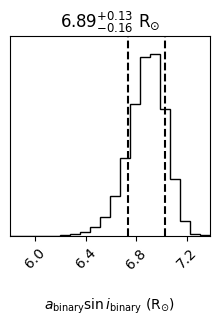

In [5]:
b.add_solver('sampler.emcee', solver='emcee_solver', overwrite=True)
b.add_distribution({'sma@binary': phoebe.gaussian_around(0.1,),
                   'incl@binary': phoebe.gaussian_around(5),
                   't0_supconj': phoebe.gaussian_around(0.001),
                   'requiv@primary': phoebe.uniform(1.55, 2.35),
                   'pblum@primary': phoebe.gaussian_around(0.4),
                   'pblum@primary': phoebe.gaussian_around(0.2),
                   'sigmas_lnf@lc01': phoebe.uniform(-1e9, -1e4),
                   }, distribution='ball_around_guess', overwrite_all=True)
b.run_compute(compute='fastcompute', sample_from='ball_around_guess', 
              sample_num=20, model='init_from_model', overwrite=True)

_ = b.plot(dataset='lc01', x='phases', 
           marker={'dataset': '.'},
           model='init_from_model', show=True)
_ = b.plot(dataset='lc01', x='phases', y='residuals',
           z={'dataset': 0, 'model': 1},
           model='init_from_model', show=True)

b.set_value('init_from', 'ball_around_guess')

_ = b.plot_distribution_collection(distribution='ball_around_guess', parameters=['asini@binary'])

b.add_distribution({'asini@binary': phoebe.gaussian(6.8, 0.2)},
                   distribution='priors_from_external_source', overwrite_all=True)

b.set_value('priors', 'priors_from_external_source')

b.set_value('nwalkers', solver='emcee_solver', value=12) #nwalkers = 2 * (number of distributions)
b.set_value('niters', solver='emcee_solver', value=250)

b.disable_dataset('rv01', compute='fastcompute')

In [ ]:
b.run_solver('emcee_solver', solution='emcee_sol')

print(b.get_parameter('adopt_parameters', solution='emcee_sol'))

Connection to online passbands at https://tables.phoebe-project.org could not be established.  Check your internet connection or try again later (can manually call phoebe.list_online_passbands(refresh=True) to retry).  If the problem persists and you're using a Mac, you may need to update openssl (see https://phoebe-project.org/help/faq). Original error from urlopen: URLError <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>
Connection to online passbands at https://tables.phoebe-project.org could not be established.  Check your internet connection or try again later (can manually call phoebe.list_online_passbands(refresh=True) to retry).  If the problem persists and you're using a Mac, you may need to update openssl (see https://phoebe-project.org/help/faq). Original error from urlopen: URLError <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate

  0%|          | 0/12 [00:00<?, ?it/s]

Connection to online passbands at https://tables.phoebe-project.org could not be established.  Check your internet connection or try again later (can manually call phoebe.list_online_passbands(refresh=True) to retry).  If the problem persists and you're using a Mac, you may need to update openssl (see https://phoebe-project.org/help/faq). Original error from urlopen: URLError <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>
Connection to online passbands at https://tables.phoebe-project.org could not be established.  Check your internet connection or try again later (can manually call phoebe.list_online_passbands(refresh=True) to retry).  If the problem persists and you're using a Mac, you may need to update openssl (see https://phoebe-project.org/help/faq). Original error from urlopen: URLError <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate

  0%|          | 0/250 [00:00<?, ?it/s]/Users/kylechen/phoebe-env/lib/python3.11/site-packages/phoebe/parameters/parameters.py:3866: RuntimeWarning: overflow encountered in exp
  sigmas2 += model_interp.value**2 * np.exp(2 * sigmas_lnf)
/Users/kylechen/phoebe-env/lib/python3.11/site-packages/phoebe/parameters/parameters.py:3866: RuntimeWarning: overflow encountered in exp
  sigmas2 += model_interp.value**2 * np.exp(2 * sigmas_lnf)
/Users/kylechen/phoebe-env/lib/python3.11/site-packages/phoebe/parameters/parameters.py:3866: RuntimeWarning: overflow encountered in exp
  sigmas2 += model_interp.value**2 * np.exp(2 * sigmas_lnf)
/Users/kylechen/phoebe-env/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
  0%|          | 1/250 [00:14<59:26, 14.32s/it]/Users/kylechen/phoebe-env/lib/python3.11/site-packages/phoebe/parameters/parameters.py:3866: RuntimeWarning: overflow encountered in e